# Extract Sentinel-1 L2 OCN Metadata and Download Copernicus Marine Data

This notebook demonstrates how to:
1. Load L2 Sentinel-1 ocean data using satpy
2. Extract geographic bounds and temporal parameters
3. Use these parameters to download ocean data from Copernicus Marine


## Step 1: Import Libraries

In [1]:
import json
import os
from datetime import datetime

import copernicusmarine
from satpy import Scene, find_files_and_readers

/home/chvan0015/miniforge3/envs/pysat_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Define Search Parameters

In [4]:
# Sentinel-1 data parameters
base_dir = "/home/chvan0015/Documents/data/sentinel1/SAFE_files/L2_OCN/test/"
base_dir = "./data/2026-01-01-000000-2026-01-02-000000_-180.00_180.00_-60.00_60.00/S1_L2_OCN/"
start_time = datetime(2025, 6, 3, 0, 49, 13)
end_time = datetime(2026, 6, 4, 15, 49, 40)
reader = 'safe_sar_l2_ocn'

print(f"Base directory: {base_dir}")
print(f"Time range: {start_time} to {end_time}")
print(f"Reader: {reader}")

Base directory: ./data/2026-01-01-000000-2026-01-02-000000_-180.00_180.00_-60.00_60.00/S1_L2_OCN/
Time range: 2025-06-03 00:49:13 to 2026-06-04 15:49:40
Reader: safe_sar_l2_ocn


## Step 3: Find and Load Sentinel-1 Data

In [5]:
# Find files matching the criteria
print("Searching for files...")
files = find_files_and_readers(
    base_dir=base_dir,
    start_time=start_time,
    end_time=end_time,
    reader=reader
)

print(f"Found {len(files)} file(s)")
for i, (fname, filereader) in enumerate(files.items()):
    print(f"  {i+1}. {fname}")

Searching for files...
Found 1 file(s)
  1. safe_sar_l2_ocn


## Step 4: Load Scene and Extract Metadata

In [6]:
# Create Scene object
print("Loading scene...")
scn = Scene(reader=reader, filenames=files)

print("\nScene info:")
print(f"  Start time: {scn.start_time}")
print(f"  End time: {scn.end_time}")
print(f"  Available datasets: {len(scn.all_dataset_names())} datasets")
print(f"  Dataset names: {list(scn.all_dataset_names())[:]}...")

Loading scene...

Scene info:
  Start time: 2026-01-01 21:17:40
  End time: 2026-01-01 21:18:44
  Available datasets: 24 datasets
  Dataset names: ['owiCalConstInci', 'owiCalConstObsi', 'owiDirmet', 'owiEcmwfWindDirection', 'owiEcmwfWindSpeed', 'owiElevationAngle', 'owiHeading', 'owiHs', 'owiIncidenceAngle', 'owiInversionQuality', 'owiLat', 'owiLon', 'owiMask', 'owiNesz', 'owiNrcs', 'owiNrcsCmod', 'owiNrcsNeszCorr', 'owiPBright', 'owiPolarisationName', 'owiWindDirection', 'owiWindQuality', 'owiWindSeaHs', 'owiWindSpeed', 'owiWl']...


In [95]:
# get orbit information from manifest.safe

import xml.etree.ElementTree as ET


def get_orbit_direction(manifest_path: str) -> str:
    tree = ET.parse(manifest_path)
    root = tree.getroot()

    # define namespaces used in the manifest
    ns = {
        "safe": "http://www.esa.int/safe/sentinel-1.0",
        "s1":   "http://www.esa.int/safe/sentinel-1.0/sentinel-1",
    }

    # find the <s1:pass> element under orbitReference/extension/orbitProperties
    elem = root.find(
        './/safe:orbitReference/safe:extension/s1:orbitProperties/s1:pass',
        ns
    )

    if elem is None or elem.text is None:
        raise ValueError("Could not find orbit direction in manifest.safe")

    return elem.text.strip()   # 'ASCENDING' or 'DESCENDING'

# usage
direction = get_orbit_direction("/home/chvan0015/Documents/data/sentinel1/SAFE_files/S1C_IW_OCN__2SDV_20260603T053123_20260603T053148_007937_01023D_3B90.SAFE/manifest.safe")
print(direction)

DESCENDING


## Step 5: Extract Geographic Bounds

In [96]:
import numpy as np

# Get area information
# Load the dataset first
scn.load(['owiHs'])
ws = scn["owiHs"]
area = ws.attrs.get("area", None)
    
# Try explicit lon/lat coords first
lon_key = next((k for k in ["longitude", "lon", "LONGITUDE"] if k in ws.coords), None)
lat_key = next((k for k in ["latitude", "lat", "LATITUDE"] if k in ws.coords), None)

if lon_key is not None and lat_key is not None:
    lon = np.asarray(ws.coords[lon_key].values, dtype=float)
    lat = np.asarray(ws.coords[lat_key].values, dtype=float)
else:
    # Fallback: derive lon/lat from Satpy area definition
    area = ws.attrs.get("area", None)
    if area is None:
        raise ValueError(
            "No explicit lat/lon coords and no area metadata. "
            f"coords={list(ws.coords)}, attrs={list(ws.attrs)}"
        )
    lon, lat = area.get_lonlats()
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)


print(f"Longitude range: {lon.min()} to {lon.max()}")
print(f"Latitude range: {lat.min()} to {lat.max()}")

Longitude range: 9.283843994140625 to 14.121105194091797
Latitude range: 56.316898345947266 to 58.218631744384766


## Step 6: Format Parameters for Copernicus Marine

In [97]:
# Format datetime strings (ISO 8601 format with Z suffix)
# Extend by ±1 hour
from datetime import timedelta

start_dt_extended = scn.start_time - timedelta(hours=1)
end_dt_extended = scn.end_time + timedelta(hours=1)

start_datetime = start_dt_extended.strftime("%Y-%m-%dT%H:%M:%SZ")
start_datetime_real = scn.start_time.strftime("%Y-%m-%dT%H:%M:%SZ")
end_datetime = end_dt_extended.strftime("%Y-%m-%dT%H:%M:%SZ")

# Create parameters dictionary
params = {
    'start_datetime': start_datetime,
    'start_datetime_real': start_datetime_real,
    'end_datetime': end_datetime,
    'minimum_longitude': lon.min(),
    'maximum_longitude': lon.max(),
    'minimum_latitude': lat.min(),
    'maximum_latitude': lat.max(),
}

print("\n" + "="*70)
print("EXTRACTED PARAMETERS FOR copernicusmarine.subset()")
print("="*70)
for key, value in params.items():
    print(f"{key}: {value}")
print("="*70)


EXTRACTED PARAMETERS FOR copernicusmarine.subset()
start_datetime: 2026-06-03T04:31:20Z
start_datetime_real: 2026-06-03T05:31:20Z
end_datetime: 2026-06-03T06:31:50Z
minimum_longitude: 9.283843994140625
maximum_longitude: 14.121105194091797
minimum_latitude: 56.316898345947266
maximum_latitude: 58.218631744384766


## Step 7: Save Parameters to JSON

In [98]:
output_directory_general = f"copernicus-data/{params['start_datetime_real']}"
output_filename = "parameters_sentinel1.json"
output_path = os.path.join(output_directory_general, output_filename)

# Create the directory structure if it doesn't exist
os.makedirs(output_directory_general, exist_ok=True)

# Save to JSON file for reference
with open(output_path, 'w') as f:
    json.dump(params, f, indent=2)

print(f"Parameters saved to '{output_path}'")
print("\nJSON content:")
print(json.dumps(params, indent=2))

Parameters saved to 'copernicus-data/2026-06-03T05:31:20Z/parameters_sentinel1.json'

JSON content:
{
  "start_datetime": "2026-06-03T04:31:20Z",
  "start_datetime_real": "2026-06-03T05:31:20Z",
  "end_datetime": "2026-06-03T06:31:50Z",
  "minimum_longitude": 9.283843994140625,
  "maximum_longitude": 14.121105194091797,
  "minimum_latitude": 56.316898345947266,
  "maximum_latitude": 58.218631744384766
}


## Step 8: Download Copernicus Marine Data Subset (Optional)

Uncomment and modify the code below to actually download ocean data.

In [99]:
# Download multiple Copernicus Marine datasets
# Note: You need to:
# 1. Have Copernicus credentials set up
# 2. Know the dataset_id for the ocean data you want
# 3. Specify which variables to download

dataset_ids = [
    "cmems_obs-wave_glo_phy-swh_nrt_cfo-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_c2-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_h2b-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_h2c-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_j3-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_al-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_s3a-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_s3b-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_s6a-l3_PT1S",
    "cmems_obs-wave_glo_phy-swh_nrt_swon-l3_PT1S"
]

variables = ["VAVH", "VAVH_UNFILTERED", "WIND_SPEED"]
output_directory = output_directory_general + "/ocean_subset"

# Pre-check: verify if any output files already exist
print(f"\n{'='*70}")
print("CHECKING FOR EXISTING FILES...")
print(f"{'='*70}")

output_paths_to_check = []
for dataset_id in dataset_ids:
    dataset_name = dataset_id.split('nrt_')[1].split('-l3')[0]
    output_filename = f"{dataset_name}.nc"
    output_path = os.path.join(output_directory, output_filename[:-3])
    output_paths_to_check.append((dataset_name, output_path))

existing_files = {name: path for name, path in output_paths_to_check if os.path.exists(path)}

if existing_files:
    print(f"\n✓ Found {len(existing_files)} existing file(s):")
    for dataset_name, path in existing_files.items():
        print(f"  - {path}")
    print(f"\n{'='*70}")
    print("SKIPPING DOWNLOAD: At least one dataset already present")
    print("(To re-download, delete the existing files first)")
    print(f"{'='*70}\n")
else:
    # No existing files found, proceed with downloads
    print("No existing files found. Proceeding with downloads...")
    print(f"{'='*70}\n")
    
    results = []
    downloaded_files = {}  # Dictionary to store successfully downloaded file paths
    
    for dataset_id in dataset_ids:
        # Extract dataset name from dataset_id (e.g., 'cfo', 'c2', etc.)
        dataset_name = dataset_id.split('nrt_')[1].split('-l3')[0]
        output_filename = f"{dataset_name}.nc"
        output_path = os.path.join(output_directory, output_filename)
        
        print(f"\n{'='*70}")
        print(f"Downloading {dataset_id}...")
        print(f"Output: {output_filename}")
        print(f"Variables: {variables}")
        print(f"Bounds: [{params['minimum_longitude']}, {params['maximum_longitude']}] x "
              f"[{params['minimum_latitude']}, {params['maximum_latitude']}]")
        print(f"Time: {params['start_datetime']} to {params['end_datetime']}")
        print(f"{'='*70}")
        
        try:
            result = copernicusmarine.subset(
                dataset_id=dataset_id,
                variables=variables,
                minimum_longitude=params['minimum_longitude'],
                maximum_longitude=params['maximum_longitude'],
                minimum_latitude=params['minimum_latitude'],
                maximum_latitude=params['maximum_latitude'],
                start_datetime=params['start_datetime'],
                end_datetime=params['end_datetime'],
                output_filename=output_filename,
                output_directory=output_directory,
            )
            print(f"✓ Downloaded to: {result}")
            results.append((dataset_name, result))
            
            # Store file path if file_names is not empty
            if hasattr(result, 'file_names') and result.file_names and len(result.file_names) > 0:
                file_path = result.file_names[0]
                downloaded_files[dataset_name] = file_path
                print(f"  File stored: {dataset_name} -> {file_path}")
            else:
                print(f"  Warning: No file_names attribute or empty list for {dataset_name}")
        except Exception as e:
            print(f"✗ Error downloading {dataset_id}: {e}")
            results.append((dataset_name, f"ERROR: {e}"))
    
    print(f"\n{'='*70}")
    print("DOWNLOAD SUMMARY")
    print(f"{'='*70}")
    for dataset_name, result in results:
        status = "✓" if isinstance(result, str) and not result.startswith("ERROR") else "✗"
        print(f"{status} {dataset_name}: {result}")
    
    print(f"\n{'='*70}")
    print("STORED FILE LOCATIONS")
    print(f"{'='*70}")
    if downloaded_files:
        for dataset_name, file_path in downloaded_files.items():
            print(f"{dataset_name:5s}: {file_path}")
    else:
        print("No files stored")


CHECKING FOR EXISTING FILES...
No existing files found. Proceeding with downloads...


Output: cfo.nc
Variables: ['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED']
Bounds: [9.283843994140625, 14.121105194091797] x [56.316898345947266, 58.218631744384766]
Time: 2026-06-03T04:31:20Z to 2026-06-03T06:31:50Z


INFO - 2026-06-10T12:57:33Z - Selected dataset version: "202211"
INFO - 2026-06-10T12:57:33Z - Selected dataset part: "default"
100%|██████████| [00:00<00:00]
INFO - 2026-06-10T12:57:34Z - No data found for the given parameters. Please check your request and try again.


✓ Downloaded to: file_path=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset/cfo') output_directory=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset') filename='cfo' file_size=None data_transfer_size=None variables=['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED'] coordinates_extent=[] status='000' message='The request was successful.' file_status='DOWNLOADED' file_names=None

Output: c2.nc
Variables: ['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED']
Bounds: [9.283843994140625, 14.121105194091797] x [56.316898345947266, 58.218631744384766]
Time: 2026-06-03T04:31:20Z to 2026-06-03T06:31:50Z


INFO - 2026-06-10T12:57:35Z - Selected dataset version: "202211"
INFO - 2026-06-10T12:57:35Z - Selected dataset part: "default"
100%|██████████| [00:00<00:00]
INFO - 2026-06-10T12:57:36Z - No data found for the given parameters. Please check your request and try again.


✓ Downloaded to: file_path=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset/c2') output_directory=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset') filename='c2' file_size=None data_transfer_size=None variables=['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED'] coordinates_extent=[] status='000' message='The request was successful.' file_status='DOWNLOADED' file_names=None

Output: h2b.nc
Variables: ['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED']
Bounds: [9.283843994140625, 14.121105194091797] x [56.316898345947266, 58.218631744384766]
Time: 2026-06-03T04:31:20Z to 2026-06-03T06:31:50Z


...

✓ Downloaded to: file_path=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset/s3b') output_directory=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset') filename='s3b' file_size=None data_transfer_size=None variables=['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED'] coordinates_extent=[] status='000' message='The request was successful.' file_status='DOWNLOADED' file_names=None

Output: s6a.nc
Variables: ['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED']
Bounds: [9.283843994140625, 14.121105194091797] x [56.316898345947266, 58.218631744384766]
Time: 2026-06-03T04:31:20Z to 2026-06-03T06:31:50Z


INFO - 2026-06-10T12:57:48Z - Selected dataset version: "202211"
INFO - 2026-06-10T12:57:48Z - Selected dataset part: "default"
100%|██████████| [00:00<00:00]
INFO - 2026-06-10T12:57:49Z - No data found for the given parameters. Please check your request and try again.


✓ Downloaded to: file_path=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset/s6a') output_directory=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset') filename='s6a' file_size=None data_transfer_size=None variables=['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED'] coordinates_extent=[] status='000' message='The request was successful.' file_status='DOWNLOADED' file_names=None

Output: swon.nc
Variables: ['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED']
Bounds: [9.283843994140625, 14.121105194091797] x [56.316898345947266, 58.218631744384766]
Time: 2026-06-03T04:31:20Z to 2026-06-03T06:31:50Z


INFO - 2026-06-10T12:57:50Z - Selected dataset version: "202311"
INFO - 2026-06-10T12:57:50Z - Selected dataset part: "default"
100%|██████████| [00:00<00:00]
INFO - 2026-06-10T12:57:51Z - No data found for the given parameters. Please check your request and try again.


✓ Downloaded to: file_path=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset/swon') output_directory=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset') filename='swon' file_size=None data_transfer_size=None variables=['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED'] coordinates_extent=[] status='000' message='The request was successful.' file_status='DOWNLOADED' file_names=None

DOWNLOAD SUMMARY
✗ cfo: file_path=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset/cfo') output_directory=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset') filename='cfo' file_size=None data_transfer_size=None variables=['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED'] coordinates_extent=[] status='000' message='The request was successful.' file_status='DOWNLOADED' file_names=None
✗ c2: file_path=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset/c2') output_directory=PosixPath('copernicus-data/2026-06-03T05:31:20Z/ocean_subset') filename='c2' file_size=None data_transf

In [102]:
# Extract satellite names from dataset IDs (part after "nrt_" and before "-l3")
satellites = [dataset_id.split("nrt_")[1].split("-l3")[0] for dataset_id in dataset_ids_5hz]

# Check if any satellite matches the downloaded files
if any(satellite in downloaded_files for satellite in satellites):
    # Run the cell logic
    print("A matching satellite file is found. Running the cell...")
else:
    print("No matching satellite file found.")

No matching satellite file found.


In [103]:
# Now download the 5Hz resolution datasets
dataset_ids_5hz = [
    "cmems_obs-wave_glo_phy-swh_nrt_c2-l3-1km_PT0.2S-i",
    "cmems_obs-wave_glo_phy-swh_nrt_j3-l3-1km_PT0.2S-i",
    "cmems_obs-wave_glo_phy-swh_nrt_al-l3-1km_PT0.2S-i",
    "cmems_obs-wave_glo_phy-swh_nrt_s3a-l3-1km_PT0.2S-i",
    "cmems_obs-wave_glo_phy-swh_nrt_s3b-l3-1km_PT0.2S-i",
    "cmems_obs-wave_glo_phy-swh_nrt_s6a-l3-1km_PT0.2S-i",
]

# Extract satellite names from dataset IDs (part after "nrt_" and before "-l3")
satellites = [dataset_id.split("nrt_")[1].split("-l3")[0] for dataset_id in dataset_ids_5hz]

# Check if any satellite matches the downloaded files
if any(satellite in downloaded_files for satellite in satellites):
    # Run the cell logic

    variables = ["VAVH", "VAVH_UNFILTERED"]
    output_directory_5hz = output_directory_general + "/ocean_subset_5hz"

    # Pre-check: verify if any output files already exist
    print(f"\n{'='*70}")
    print("CHECKING FOR EXISTING 5Hz FILES...")
    print(f"{'='*70}")

    output_paths_5hz_to_check = []
    for dataset_id in dataset_ids_5hz:
        dataset_name = dataset_id.split('nrt_')[1].split('-l3')[0]
        output_filename = f"ocean_subset_{dataset_name}.nc"
        output_path = os.path.join(output_directory_5hz, output_filename[:-3])
        output_paths_5hz_to_check.append((dataset_name, output_path))

    existing_files_5hz = [path for name, path in output_paths_5hz_to_check if os.path.exists(path)]

    if existing_files_5hz:
        print(f"\n✓ Found {len(existing_files_5hz)} existing file(s):")
        for path in existing_files_5hz:
            print(f"  - {path}")
        print(f"\n{'='*70}")
        print("SKIPPING DOWNLOAD: At least one 5Hz dataset already present")
        print("(To re-download, delete the existing files first)")
        print(f"{'='*70}\n")
    else:
        # No existing files found, proceed with downloads
        print("No existing 5Hz files found. Proceeding with downloads...")
        print(f"{'='*70}\n")
        
        results = []
        
        for dataset_id in dataset_ids_5hz:
            # Extract dataset name from dataset_id (e.g., 'cfo', 'c2', etc.)
            dataset_name = dataset_id.split('nrt_')[1].split('-l3')[0]
            output_filename = f"ocean_subset_{dataset_name}.nc"
            output_path = os.path.join(output_directory_5hz, output_filename)
            
            print(f"\n{'='*70}")
            print(f"Downloading {dataset_id}...")
            print(f"Output: {output_filename}")
            print(f"Variables: {variables}")
            print(f"Bounds: [{params['minimum_longitude']}, {params['maximum_longitude']}] x "
                f"[{params['minimum_latitude']}, {params['maximum_latitude']}]")
            print(f"Time: {params['start_datetime']} to {params['end_datetime']}")
            print(f"{'='*70}")
            
            try:
                result = copernicusmarine.subset(
                    dataset_id=dataset_id,
                    variables=variables,
                    minimum_longitude=params['minimum_longitude'],
                    maximum_longitude=params['maximum_longitude'],
                    minimum_latitude=params['minimum_latitude'],
                    maximum_latitude=params['maximum_latitude'],
                    start_datetime=params['start_datetime'],
                    end_datetime=params['end_datetime'],
                    output_filename=output_filename,
                    output_directory=output_directory_5hz,
                )
                print(f"✓ Downloaded to: {result}")
                results.append((dataset_name, result))
                
                # Store file path if file_names is not empty
                if hasattr(result, 'file_names') and result.file_names and len(result.file_names) > 0:
                    file_path = result.file_names[0]
                    downloaded_files[dataset_name] = file_path
                    print(f"  File stored: {dataset_name} -> {file_path}")
                else:
                    print(f"  Warning: No file_names attribute or empty list for {dataset_name}")
            except Exception as e:
                print(f"✗ Error downloading {dataset_id}: {e}")
                results.append((dataset_name, f"ERROR: {e}"))
        
        print(f"\n{'='*70}")
        print("DOWNLOAD SUMMARY")
        print(f"{'='*70}")
        for dataset_name, result in results:
            status = "✓" if isinstance(result, str) and not result.startswith("ERROR") else "✗"
            print(f"{status} {dataset_name}: {result}")
        
        print(f"\n{'='*70}")
        print("STORED FILE LOCATIONS")
        print(f"{'='*70}")
        if downloaded_files:
            for dataset_name, file_path in downloaded_files.items():
                print(f"{dataset_name:5s}: {file_path}")
        else:
            print("No files stored")

else:
    print("No 1 Hz datasets available for any of the satellites, so not downloading 5 Hz datasets.")

No 1 Hz datasets available for any of the satellites, so not downloading 5 Hz datasets.


In [104]:
# Display the downloaded files dictionary for easy access
print("\n" + "="*70)
print("DOWNLOADED FILES DICTIONARY")
print("="*70)
print(f"Total files stored: {len(downloaded_files)}")
print("\nAccess file paths like this:")
for dataset_name in downloaded_files.keys():
    print(f"  downloaded_files['{dataset_name}'] = {downloaded_files[dataset_name]}")
print("="*70)



DOWNLOADED FILES DICTIONARY
Total files stored: 1

Access file paths like this:
  downloaded_files['h2b'] = HaiYang-2B.nc


## Summary

The extracted parameters are ready to use with `copernicusmarine.subset()`:

```python
copernicusmarine.subset(
    dataset_id="your_dataset_id",
    variables=["var1", "var2"],
    minimum_longitude={params['minimum_longitude']},
    maximum_longitude={params['maximum_longitude']},
    minimum_latitude={params['minimum_latitude']},
    maximum_latitude={params['maximum_latitude']},
    start_datetime="{params['start_datetime']}",
    end_datetime="{params['end_datetime']}",
    output_filename="subset.nc",
    output_directory="copernicus-data",
)
```

## Step 9: Compare Downloaded Data with Sentinel-1 Measurements


In [120]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.backends.backend_pdf import PdfPages

# Load Sentinel-1 data once
scn.load(['owiHs'])
scn.load(['owiWindSpeed'])
s1_owiHs = scn["owiHs"]
s1_owiWindSpeed = scn["owiWindSpeed"]

s1_lat = np.asarray(s1_owiHs.coords['latitude'].values, dtype=float) if 'latitude' in s1_owiHs.coords else lat
s1_lon = np.asarray(s1_owiHs.coords['longitude'].values, dtype=float) if 'longitude' in s1_owiHs.coords else lon
s1_lat_center = s1_lat.mean()
s1_lon_center = s1_lon.mean()
s1_time = scn.start_time

print("="*70)
print("STEP 9: COMPARING GLOBAL OCEAN SIGNIFICANT WAVE HEIGHT DATASETS (FROM ALTIMETER DATA) WITH SENTINEL-1")
print("="*70)

for dataset_name, nc_filepath in downloaded_files.items():
    print(f"\n{'='*70}")
    print(f"Processing: {dataset_name}")
    print(f"File: {nc_filepath}")
    print(f"{'='*70}")
    
    try:
        # Load the dataset
        altimeter_data = xr.open_dataset(nc_filepath)
        print("\nDataset Info:")
        print(f"  Dimensions: {dict(altimeter_data.dims)}")
        print(f"  Variables: {list(altimeter_data.data_vars)}")

# Extract variables
        # Time
        if 'time' in altimeter_data.coords:
            scatter_time = altimeter_data['time'].values
            scatter_time_center = np.datetime64(scatter_time[len(scatter_time)//2])
            scatter_time_dt = pd.Timestamp(scatter_time_center).to_pydatetime()
            print(f"\n  Time range: {scatter_time[0]} to {scatter_time[-1]}")
            print(f"  Center time: {scatter_time_center}")
            time_offset = scatter_time_dt - s1_time
            print(f"  Time offset (scatterometer center - Sentinel-1 start): {time_offset}")
        
        # Latitude/Longitude
        lat_names = [k for k in altimeter_data.coords.keys() if k.lower() in ['latitude', 'lat']]
        lon_names = [k for k in altimeter_data.coords.keys() if k.lower() in ['longitude', 'lon']]
        
        if lat_names and lon_names:
            lat_name = lat_names[0]
            lon_name = lon_names[0]
            scatter_lat = altimeter_data[lat_name].values
            scatter_lon = altimeter_data[lon_name].values
            scatter_lat_center = scatter_lat.mean()
            scatter_lon_center = scatter_lon.mean()
            print(f"\n  Latitude range: {scatter_lat.min():.2f} to {scatter_lat.max():.2f}")
            print(f"  Longitude range: {scatter_lon.min():.2f} to {scatter_lon.max():.2f}")
            
            lat_offset = scatter_lat_center - s1_lat_center
            lon_offset = scatter_lon_center - s1_lon_center
            print("\n  Spatial offset (altimeter center - Sentinel-1 center):")
            print(f"    Latitude: {lat_offset:.4f}° ({lat_offset * 111:.2f} km)")
            print(f"    Longitude: {lon_offset:.4f}° ({lon_offset * 111 * np.cos(np.deg2rad(s1_lat_center)):.2f} km)")
        
        # Wave height
        wave_height_names = [k for k in altimeter_data.data_vars if 'VAHV' in k.lower() or 'VAHV' in k.lower()]
        if wave_height_names:
            wave_height_name = wave_height_names[0]
            scatter_wave_height = altimeter_data[wave_height_name]
            print(f"\n  Wave Height ('{wave_height_name}'):")
            print(f"    Shape: {scatter_wave_height.shape}")
            print(f"    Range: {float(scatter_wave_height.min()):.2f} to {float(scatter_wave_height.max()):.2f}°")
            print(f"    Mean: {float(scatter_wave_height.mean()):.2f}°")
        
        # Wind speed
        wind_speed_names = [k for k in altimeter_data.data_vars if 'wind' in k.lower() and 'speed' in k.lower()]
        if wind_speed_names:
            wind_speed_name = wind_speed_names[0]
            scatter_wind_speed = altimeter_data[wind_speed_name]
            print(f"\n  Wind Speed ('{wind_speed_name}'):")
            print(f"    Shape: {scatter_wind_speed.shape}")
            print(f"    Range: {float(scatter_wind_speed.min()):.2f} to {float(scatter_wind_speed.max()):.2f} m/s")
            print(f"    Mean: {float(scatter_wind_speed.mean()):.2f} m/s")
        
        # Statistical comparison with Sentinel-1
        print("\n  Statistical Comparison with Sentinel-1:")
        print(f"    Sentinel-1 owiHs range: {float(s1_owiHs.min()):.2f} to {float(s1_owiHs.max()):.2f}°")
        print(f"    Sentinel-1 owiHs mean: {float(s1_owiHs.mean()):.2f}°")
        
        if wave_height_names:
            diff_wave_height_mean = float(scatter_wave_height.mean()) - float(s1_owiHs.mean())
            print("\n    Wave Height Difference (mean):")
            print(f"      {dataset_name} - Sentinel-1: {diff_wave_height_mean:.2f}°")
            print(f"      Percent difference: {(abs(diff_wave_height_mean)/max(1, abs(float(s1_owiHs.mean()))))*100:.1f}%")
        
        print(f"\n    Sentinel-1 owiWindSpeed range: {float(s1_owiWindSpeed.min()):.2f} to {float(s1_owiWindSpeed.max()):.2f} m/s")
        print(f"    Sentinel-1 owiWindSpeed mean: {float(s1_owiWindSpeed.mean()):.2f} m/s")
        
        if wind_speed_names:
            diff_speed_mean = float(scatter_wind_speed.mean()) - float(s1_owiWindSpeed.mean())
            print("\n    Wind Speed Difference (mean):")
            print(f"      {dataset_name} - Sentinel-1: {diff_speed_mean:.2f} m/s")
            print(f"      Percent difference: {(diff_speed_mean/float(s1_owiWindSpeed.mean()))*100:.1f}%")
        
        # Create PDF with comparison plots
        nc_filepath1 = output_directory + "/" + os.path.basename(nc_filepath)
        pdf_filepath = nc_filepath1.replace('.nc', '.pdf')
        print("\n  Creating comparison plots...")
        
        with PdfPages(pdf_filepath) as pdf:
            # Page 1: Dataset info and statistics
            fig = plt.figure(figsize=(11, 8.5))
            fig.suptitle(f'Scatterometer Comparison: {dataset_name}', fontsize=16, fontweight='bold')
            
            ax = fig.add_subplot(111)
            ax.axis('off')
            
            # Summary text
            summary_text = f"""
Dataset: {dataset_name}
File: {os.path.basename(nc_filepath1)}
Comparison Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

ALTIMETER DATA:
  Variables: {', '.join(list(altimeter_data.data_vars))}
  Dimensions: {dict(altimeter_data.dims)}
  
  Time range: {scatter_time[0]} to {scatter_time[-1]}
  Spatial range: Lat [{scatter_lat.min():.2f}, {scatter_lat.max():.2f}], Lon [{scatter_lon.min():.2f}, {scatter_lon.max():.2f}]
  
WAVE HEIGHT:
  Altimeter mean: {float(scatter_wave_height.mean()):.2f}° (range: {float(scatter_wave_height.min()):.2f} to {float(scatter_wave_height.max()):.2f}°)
  Sentinel-1 mean: {float(s1_owiHs.mean()):.2f}° (range: {float(s1_owiHs.min()):.2f} to {float(s1_owiHs.max()):.2f}°)
  Difference: {diff_wave_height_mean:.2f}°

WIND SPEED:
  Altimeter mean: {float(scatter_wind_speed.mean()):.2f} m/s (range: {float(scatter_wind_speed.min()):.2f} to {float(scatter_wind_speed.max()):.2f} m/s)
  Sentinel-1 mean: {float(s1_owiWindSpeed.mean()):.2f} m/s (range: {float(s1_owiWindSpeed.min()):.2f} to {float(s1_owiWindSpeed.max()):.2f} m/s)
  Difference: {diff_speed_mean:.2f} m/s ({(diff_speed_mean/float(s1_owiWindSpeed.mean()))*100:.1f}%)

TEMPORAL OFFSET:
  Time difference: {time_offset}

SPATIAL OFFSET:
  Latitude: {lat_offset:.4f}° ({lat_offset * 111:.2f} km)
  Longitude: {lon_offset:.4f}° ({lon_offset * 111 * np.cos(np.deg2rad(s1_lat_center)):.2f} km)
            """
            
            ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
                   verticalalignment='top', family='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
            
            # Page 2: Wave height comparison
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            ax1.hist(s1_owiHs.values.flatten(), bins=50, alpha=0.7, label='Sentinel-1', edgecolor='black')
            ax1.set_xlabel('Wave Height (meters)')
            ax1.set_ylabel('Frequency')
            ax1.set_title('Sentinel-1 Wave Height Distribution')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            ax2.hist(scatter_wave_height.values.flatten(), bins=50, alpha=0.7, label=dataset_name, color='orange', edgecolor='black')
            ax2.set_xlabel('Wave Height (meters)')
            ax2.set_ylabel('Frequency')
            ax2.set_title(f'{dataset_name} Wave Height Distribution')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            fig.suptitle('Wave Height Comparison', fontsize=14, fontweight='bold')
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
            
            # Page 3: Wind speed comparison
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            ax1.hist(s1_owiWindSpeed.values.flatten(), bins=50, alpha=0.7, label='Sentinel-1', edgecolor='black')
            ax1.set_xlabel('Wind Speed (m/s)')
            ax1.set_ylabel('Frequency')
            ax1.set_title('Sentinel-1 Wind Speed Distribution')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            ax2.hist(scatter_wind_speed.values.flatten(), bins=50, alpha=0.7, label=dataset_name, color='orange', edgecolor='black')
            ax2.set_xlabel('Wind Speed (m/s)')
            ax2.set_ylabel('Frequency')
            ax2.set_title(f'{dataset_name} Wind Speed Distribution')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            fig.suptitle('Wind Speed Comparison', fontsize=14, fontweight='bold')
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
        
        print(f"  ✓ PDF saved to: {pdf_filepath}")
        
    except Exception as e:
        print(f"  ✗ Error processing {dataset_name}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*70}")
print("STEP 9: COMPLETE - All comparisons saved")
print(f"{'='*70}")



STEP 9: COMPARING GLOBAL OCEAN SIGNIFICANT WAVE HEIGHT DATASETS (FROM ALTIMETER DATA) WITH SENTINEL-1

Processing: h2b
File: HaiYang-2B.nc
  ✗ Error processing h2b: [Errno 2] No such file or directory: '/home/chvan0015/git/pysat_test/HaiYang-2B.nc'

STEP 9: COMPLETE - All comparisons saved


Traceback (most recent call last):
  File "/home/chvan0015/miniforge3/envs/pysat_env/lib/python3.14/site-packages/xarray/backends/file_manager.py", line 219, in _acquire_with_cache_info
    file = self._cache[self._key]
           ~~~~~~~~~~~^^^^^^^^^^^
  File "/home/chvan0015/miniforge3/envs/pysat_env/lib/python3.14/site-packages/xarray/backends/lru_cache.py", line 56, in __getitem__
    value = self._cache[key]
            ~~~~~~~~~~~^^^^^
KeyError: [<class 'netCDF4._netCDF4.Dataset'>, ('/home/chvan0015/git/pysat_test/HaiYang-2B.nc',), 'r', (('clobber', True), ('diskless', False), ('format', 'NETCDF4'), ('persist', False)), '79f70744-151f-4286-bf12-20d948ed1f5d']

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/tmp/ipykernel_724271/692748014.py", line 33, in <module>
    altimeter_data = xr.open_dataset(nc_filepath)
  File "/home/chvan0015/miniforge3/envs/pysat_env/lib/python3.14/site-packages/xarray/backends/api.py", l

In [42]:
# Verify Step 9 file path was loaded from downloaded_files
print("\n" + "="*70)
print("FILE PATH VERIFICATION")
print("="*70)
print(f"Used file path: {h2b_file}")
print(f"Data shape: {h2b_data.dims}")
print(f"Data variables: {list(h2b_data.data_vars)}")
print(f"Successfully loaded using downloaded_files dictionary: {'h2b' in downloaded_files}")
print("="*70)



FILE PATH VERIFICATION
Used file path: copernicus-data/ocean_subset_h2b/HaiYang-2B.nc
Data shape: FrozenMappingWarningOnValuesAccess({'time': 9})
Data variables: ['VAVH', 'VAVH_UNFILTERED', 'WIND_SPEED']
Successfully loaded using downloaded_files dictionary: True


## Step 11: Geographic Coordinate Plots with HaiYang-2b Overlay


Using original hs array without downsampling


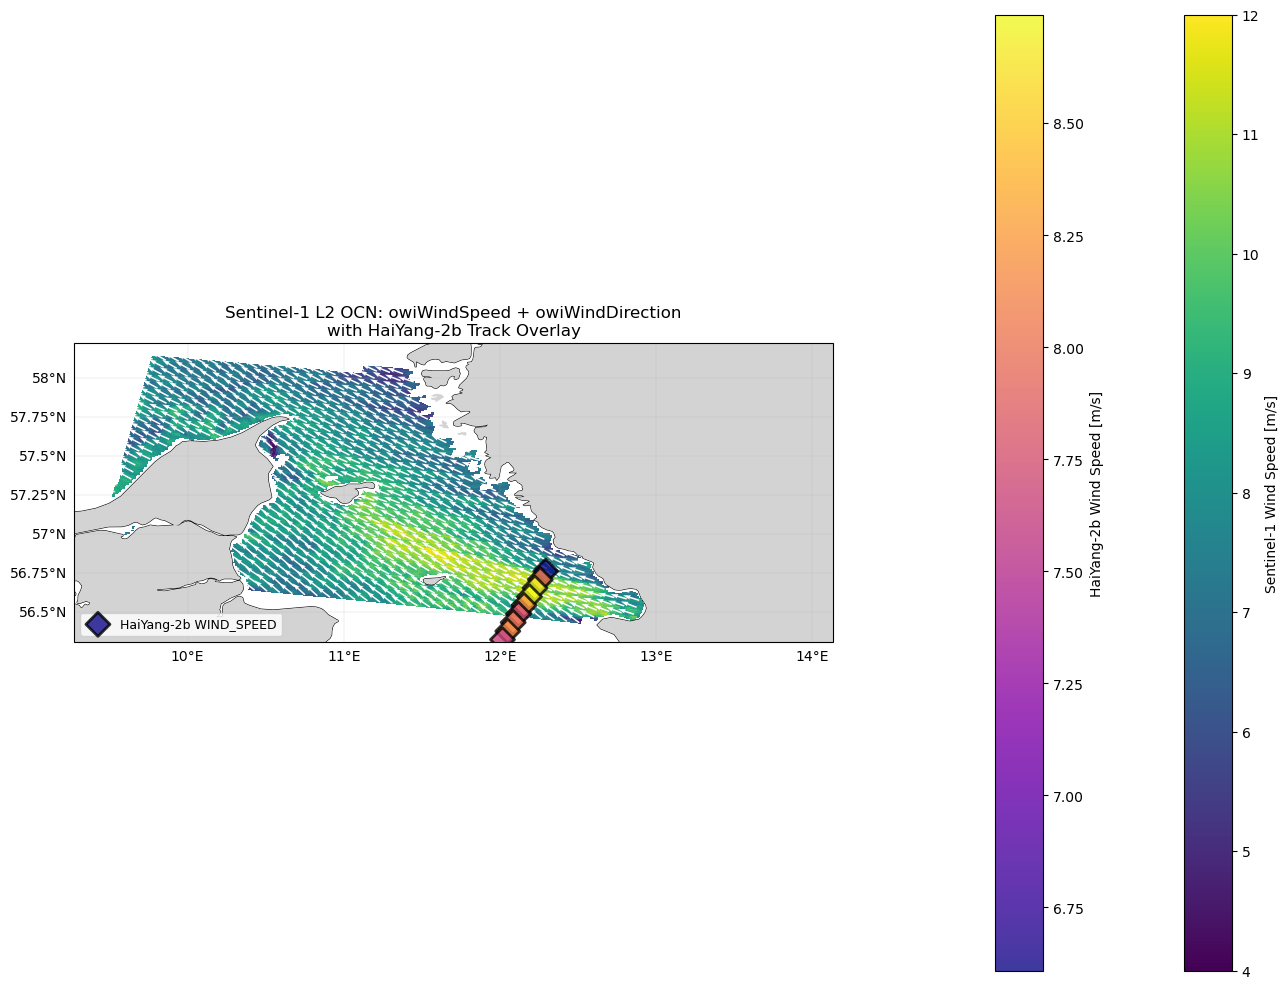

Note: owiHs has reduced dimensions. Plotting HaiYang-2b data only for wave height comparison.


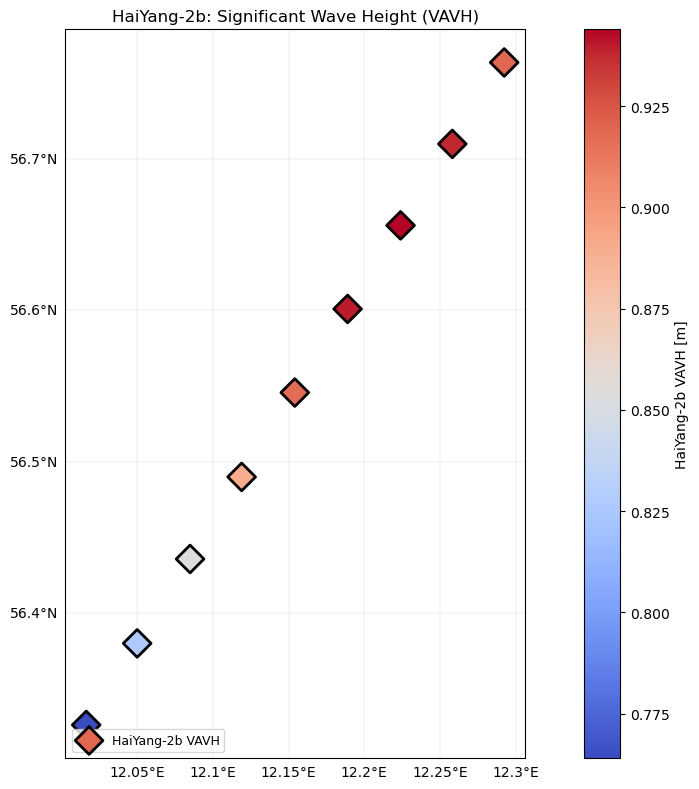

GEOGRAPHIC COORDINATE PLOTS COMPLETE
Sentinel-1 coverage: 56.32–58.22°N, 9.28–14.12°E
HaiYang-2b track:    56.33–56.76°N, 12.02–12.29°E


In [35]:
# Plot Sentinel-1 data on geographical coordinates with HaiYang-2b track overlay
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Reload Sentinel-1 datasets
scn.load(['owiWindSpeed', 'owiWindDirection', 'owiHs'])
ws = scn["owiWindSpeed"]
wd = scn["owiWindDirection"]
hs = scn["owiHs"]

ws_arr = np.asarray(ws.values, dtype=float)
wd_arr = np.asarray(wd.values, dtype=float)
hs_arr = np.asarray(hs.values, dtype=float)

# Extract lon/lat coordinates
lon_key = next((k for k in ["longitude", "lon", "LONGITUDE"] if k in ws.coords), None)
lat_key = next((k for k in ["latitude", "lat", "LATITUDE"] if k in ws.coords), None)

if lon_key is not None and lat_key is not None:
    lon_s1 = np.asarray(ws.coords[lon_key].values, dtype=float)
    lat_s1 = np.asarray(ws.coords[lat_key].values, dtype=float)
else:
    # Fallback: derive lon/lat from Satpy area definition
    area = ws.attrs.get("area", None)
    if area is None:
        raise ValueError("No lon/lat coordinates found in dataset")
    lon_s1, lat_s1 = area.get_lonlats()
    lon_s1 = np.asarray(lon_s1, dtype=float)
    lat_s1 = np.asarray(lat_s1, dtype=float)

# Downsample for plotting
step = max(1, min(ws_arr.shape) // 140)
lon_d = lon_s1[::step, ::step]
lat_d = lat_s1[::step, ::step]
ws_d = ws_arr[::step, ::step]
wd_d = wd_arr[::step, ::step]

# Handle hs separately due to potential shape mismatch
if hs_arr.size == ws_arr.size:
    hs_d = hs_arr[::step, ::step]
else:
    # If shapes don't match, flatten and reshape to match ws
    print(f"Warning: Hs shape {hs_arr.shape} differs from wind speed {ws_arr.shape}")
    print("Using original hs array without downsampling")
    hs_d = hs_arr.copy()

# Mask invalid values
valid = np.isfinite(lon_d) & np.isfinite(lat_d) & np.isfinite(ws_d) & np.isfinite(wd_d)

# Wind direction vectors
theta = np.deg2rad(wd_d)
u = -np.sin(theta)
v = -np.cos(theta)
u[~valid] = np.nan
v[~valid] = np.nan

# ===== PLOT 1: WIND SPEED WITH HAIYANG-2B OVERLAY =====
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=proj)

# Sentinel-1 wind speed
mesh = ax.pcolormesh(lon_d, lat_d, ws_d, cmap="viridis", shading="auto", transform=proj)
cb = plt.colorbar(mesh, ax=ax, pad=0.02)
cb.set_label("Sentinel-1 Wind Speed [m/s]")

# Wind direction vectors
q_step = max(1, min(ws_d.shape) // 28)
ax.quiver(
    lon_d[::q_step, ::q_step],
    lat_d[::q_step, ::q_step],
    u[::q_step, ::q_step],
    v[::q_step, ::q_step],
    color="white",
    scale=45,
    width=0.002,
    transform=proj
)

# HaiYang-2b track overlay with colorbar
scatter_wind = ax.scatter(h2b_lon, h2b_lat, c=h2b_wind.values, cmap="plasma", s=150,
                          marker='D', edgecolors='black', linewidth=2, 
                          transform=proj, zorder=5, label='HaiYang-2b WIND_SPEED',
                          alpha=0.8)

# Add colorbar for HaiYang-2b wind speed
cbar_h2b_wind = plt.colorbar(scatter_wind, ax=ax, pad=0.15)
cbar_h2b_wind.set_label("HaiYang-2b Wind Speed [m/s]")

# Map features
ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title("Sentinel-1 L2 OCN: owiWindSpeed + owiWindDirection\nwith HaiYang-2b Track Overlay", fontsize=12)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

# ===== PLOT 2: WAVE HEIGHT WITH HAIYANG-2B OVERLAY =====
# Check if hs_d is usable for pcolormesh
if hs_d.ndim >= 2 and hs_d.shape[0] > 1 and hs_d.shape[1] > 1:
    fig = plt.figure(figsize=(14, 10))
    ax = plt.axes(projection=proj)

    # Sentinel-1 wave height
    hs_d_valid = np.where(np.isfinite(hs_d), hs_d, np.nan)
    mesh = ax.pcolormesh(lon_d, lat_d, hs_d_valid, cmap="coolwarm", shading="auto", transform=proj)
    cb = plt.colorbar(mesh, ax=ax, pad=0.02)
    cb.set_label("Sentinel-1 Significant Wave Height [m]")

    # HaiYang-2b track overlay
    scatter = ax.scatter(h2b_lon, h2b_lat, c=h2b_vavh.values, cmap="plasma", s=150,
                         marker='D', edgecolors='black', linewidth=2,
                         transform=proj, zorder=5, label='HaiYang-2b VAVH',
                         alpha=0.8)

    # Add a secondary colorbar for HaiYang-2b values
    cbar2_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar2 = plt.colorbar(scatter, cax=cbar2_ax)
    cbar2.set_label("HaiYang-2b VAVH [m]", fontsize=9)

    # Map features
    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title("Sentinel-1 L2 OCN: owiHs (Significant Wave Height)\nwith HaiYang-2b Track Overlay", fontsize=12)
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Note: owiHs has reduced dimensions. Plotting HaiYang-2b data only for wave height comparison.")
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': proj})
    scatter = ax.scatter(h2b_lon, h2b_lat, c=h2b_vavh.values, cmap="coolwarm", s=200,
                         marker='D', edgecolors='black', linewidth=2,
                         transform=proj, zorder=5, label='HaiYang-2b VAVH')
    cbar = plt.colorbar(scatter, ax=ax, pad=0.05)
    cbar.set_label("HaiYang-2b VAVH [m]", fontsize=10)
    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title("HaiYang-2b: Significant Wave Height (VAVH)", fontsize=12)
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.show()

print("="*70)
print("GEOGRAPHIC COORDINATE PLOTS COMPLETE")
print("="*70)
print(f"Sentinel-1 coverage: {lat_s1.min():.2f}–{lat_s1.max():.2f}°N, {lon_s1.min():.2f}–{lon_s1.max():.2f}°E")
print(f"HaiYang-2b track:    {h2b_lat.min():.2f}–{h2b_lat.max():.2f}°N, {h2b_lon.min():.2f}–{h2b_lon.max():.2f}°E")
print("="*70)

## Step 12: Closest-Point Matching and Detailed Comparison

For each HaiYang-2b measurement, find the closest Sentinel-1 data point (using original resolution) and compare wind speed, location, and time.


In [36]:
import pandas as pd
from scipy.spatial.distance import cdist

# Ensure we have the original resolution Sentinel-1 data
scn.load(['owiWindSpeed', 'owiWindDirection'])
ws = scn["owiWindSpeed"]
wd = scn["owiWindDirection"]

ws_arr = np.asarray(ws.values, dtype=float)
wd_arr = np.asarray(wd.values, dtype=float)

# Extract original resolution coordinates
lon_key = next((k for k in ["longitude", "lon", "LONGITUDE"] if k in ws.coords), None)
lat_key = next((k for k in ["latitude", "lat", "LATITUDE"] if k in ws.coords), None)

if lon_key is not None and lat_key is not None:
    lon_s1_orig = np.asarray(ws.coords[lon_key].values, dtype=float)
    lat_s1_orig = np.asarray(ws.coords[lat_key].values, dtype=float)
else:
    area = ws.attrs.get("area", None)
    if area is None:
        raise ValueError("No lon/lat coordinates found")
    lon_s1_orig, lat_s1_orig = area.get_lonlats()
    lon_s1_orig = np.asarray(lon_s1_orig, dtype=float)
    lat_s1_orig = np.asarray(lat_s1_orig, dtype=float)

print("="*90)
print("CLOSEST-POINT MATCHING AND COMPARISON")
print("="*90)
print(f"Sentinel-1 original resolution: {ws_arr.shape}")
print(f"HaiYang-2b points: {len(h2b_lon)}")
print("="*90)

# Create a 1D array of Sentinel-1 coordinates and values
s1_points_2d = []
s1_lon_flat = []
s1_lat_flat = []
s1_wind_flat = []
s1_wd_flat = []

for i in range(lon_s1_orig.shape[0]):
    for j in range(lon_s1_orig.shape[1]):
        if np.isfinite(lon_s1_orig[i, j]) and np.isfinite(lat_s1_orig[i, j]):
            s1_points_2d.append((lon_s1_orig[i, j], lat_s1_orig[i, j]))
            s1_lon_flat.append(lon_s1_orig[i, j])
            s1_lat_flat.append(lat_s1_orig[i, j])
            if np.isfinite(ws_arr[i, j]):
                s1_wind_flat.append(ws_arr[i, j])
            else:
                s1_wind_flat.append(np.nan)
            if np.isfinite(wd_arr[i, j]):
                s1_wd_flat.append(wd_arr[i, j])
            else:
                s1_wd_flat.append(np.nan)

s1_points_2d = np.array(s1_points_2d)
s1_lon_flat = np.array(s1_lon_flat)
s1_lat_flat = np.array(s1_lat_flat)
s1_wind_flat = np.array(s1_wind_flat)
s1_wd_flat = np.array(s1_wd_flat)

print(f"Valid Sentinel-1 points: {len(s1_points_2d)}")

# Create HaiYang-2b points array
h2b_points = np.column_stack((h2b_lon, h2b_lat))

# Compute distances from each HaiYang-2b point to all Sentinel-1 points
# Use simple Euclidean distance in lat/lon space (this is acceptable for small areas)
distances = cdist(h2b_points, s1_points_2d, metric='euclidean')

# Find closest Sentinel-1 point for each HaiYang-2b measurement
closest_indices = np.argmin(distances, axis=1)
closest_distances = np.min(distances, axis=1)

# Prepare comparison data
comparison_data = []

for h2b_idx in range(len(h2b_lon)):
    s1_idx = closest_indices[h2b_idx]
    
    # Coordinates
    h2b_lon_val = h2b_lon[h2b_idx]
    h2b_lat_val = h2b_lat[h2b_idx]
    s1_lon_val = s1_lon_flat[s1_idx]
    s1_lat_val = s1_lat_flat[s1_idx]
    
    # Wind speeds
    h2b_wind_val = float(h2b_wind.values[h2b_idx])
    s1_wind_val = s1_wind_flat[s1_idx]
    
    # Calculate geographic distance in km (Haversine approximation for small distances)
    lat_mean = np.radians((h2b_lat_val + s1_lat_val) / 2)
    lon_diff_m = (h2b_lon_val - s1_lon_val) * 111321 * np.cos(lat_mean)
    lat_diff_m = (h2b_lat_val - s1_lat_val) * 110540
    distance_m = np.sqrt(lon_diff_m**2 + lat_diff_m**2)
    distance_km = distance_m / 1000
    
    # Wind speed difference
    wind_diff_abs = h2b_wind_val - s1_wind_val
    wind_diff_pct = (wind_diff_abs / s1_wind_val * 100) if s1_wind_val != 0 else np.nan
    
    # Time difference (in minutes)
    h2b_time_val = pd.Timestamp(h2b_time[h2b_idx]).to_pydatetime()
    s1_time_val = scn.start_time
    time_diff_minutes = (h2b_time_val - s1_time_val).total_seconds() / 60
    
    comparison_data.append({
        'H2B_Index': h2b_idx,
        'H2B_Lon': h2b_lon_val,
        'H2B_Lat': h2b_lat_val,
        'H2B_WindSpeed_ms': h2b_wind_val,
        'H2B_Time': h2b_time_val,
        'S1_Lon': s1_lon_val,
        'S1_Lat': s1_lat_val,
        'S1_WindSpeed_ms': s1_wind_val,
        'S1_PixelIdx': s1_idx,
        'Distance_m': distance_m,
        'Distance_km': distance_km,
        'WindSpeed_Diff_Abs_ms': wind_diff_abs,
        'WindSpeed_Diff_Pct': wind_diff_pct,
        'TimeDiff_minutes': time_diff_minutes,
    })

# Create a pandas DataFrame for easy viewing
comparison_df = pd.DataFrame(comparison_data)

# Display summary statistics
print("\n" + "="*90)
print("SPATIAL MATCHING SUMMARY")
print("="*90)
print("Distance to closest Sentinel-1 point:")
print(f"  Mean: {comparison_df['Distance_m'].mean():.2f} m ({comparison_df['Distance_km'].mean():.4f} km)")
print(f"  Min: {comparison_df['Distance_m'].min():.2f} m ({comparison_df['Distance_km'].min():.4f} km)")
print(f"  Max: {comparison_df['Distance_m'].max():.2f} m ({comparison_df['Distance_km'].max():.4f} km)")
print(f"  Median: {comparison_df['Distance_m'].median():.2f} m ({comparison_df['Distance_km'].median():.4f} km)")

print("\n" + "="*90)
print("WIND SPEED COMPARISON SUMMARY")
print("="*90)
print("Wind Speed Differences (H2B - S1):")
print(f"  Mean absolute: {comparison_df['WindSpeed_Diff_Abs_ms'].mean():.3f} m/s")
print(f"  Mean percentage: {comparison_df['WindSpeed_Diff_Pct'].mean():.1f}%")
print(f"  Std absolute: {comparison_df['WindSpeed_Diff_Abs_ms'].std():.3f} m/s")
print(f"  Std percentage: {comparison_df['WindSpeed_Diff_Pct'].std():.1f}%")
print(f"  Min absolute: {comparison_df['WindSpeed_Diff_Abs_ms'].min():.3f} m/s")
print(f"  Max absolute: {comparison_df['WindSpeed_Diff_Abs_ms'].max():.3f} m/s")

print("\n" + "="*90)
print("TEMPORAL COMPARISON SUMMARY")
print("="*90)
print("Time Differences (H2B - S1 start):")
print(f"  Mean: {comparison_df['TimeDiff_minutes'].mean():.2f} minutes")
print(f"  Min: {comparison_df['TimeDiff_minutes'].min():.2f} minutes")
print(f"  Max: {comparison_df['TimeDiff_minutes'].max():.2f} minutes")

# Display detailed comparison table
print("\n" + "="*90)
print("DETAILED COMPARISON TABLE (all HaiYang-2b points with closest Sentinel-1)")
print("="*90)

display_df = comparison_df[[
    'H2B_Index',
    'H2B_Lon', 'H2B_Lat', 'H2B_WindSpeed_ms',
    'S1_Lon', 'S1_Lat', 'S1_WindSpeed_ms',
    'Distance_m', 'WindSpeed_Diff_Abs_ms', 'WindSpeed_Diff_Pct', 'TimeDiff_minutes'
]].copy()

display_df.columns = [
    'H2B#',
    'H2B_Lon', 'H2B_Lat', 'H2B_WS',
    'S1_Lon', 'S1_Lat', 'S1_WS',
    'Dist_m', 'ΔWS_abs', 'ΔWS_%', 'ΔTime_min'
]

# Set pandas display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(display_df.to_string(index=False))

print("\n" + "="*90)
print("KEY FINDINGS")
print("="*90)
print("• Sentinel-1 and HaiYang-2b measurements are separated by:")
print(f"  - Average spatial distance: {comparison_df['Distance_m'].mean():.0f} m")
print(f"  - Average wind speed difference: {comparison_df['WindSpeed_Diff_Abs_ms'].mean():.2f} m/s "
      f"({abs(comparison_df['WindSpeed_Diff_Pct'].mean()):.1f}% "
      f"{'higher' if comparison_df['WindSpeed_Diff_Pct'].mean() > 0 else 'lower'} in HaiYang-2b)")
print(f"  - Average temporal difference: {comparison_df['TimeDiff_minutes'].mean():.1f} minutes")
print("="*90)


CLOSEST-POINT MATCHING AND COMPARISON
Sentinel-1 original resolution: (166, 267)
HaiYang-2b points: 9
Valid Sentinel-1 points: 44322

SPATIAL MATCHING SUMMARY
Distance to closest Sentinel-1 point:
  Mean: 3941.40 m (3.9414 km)
  Min: 136.45 m (0.1365 km)
  Max: 17639.19 m (17.6392 km)
  Median: 372.74 m (0.3727 km)

WIND SPEED COMPARISON SUMMARY
Wind Speed Differences (H2B - S1):
  Mean absolute: -1.360 m/s
  Mean percentage: -13.9%
  Std absolute: 0.858 m/s
  Std percentage: 8.4%
  Min absolute: -2.627 m/s
  Max absolute: 0.053 m/s

TEMPORAL COMPARISON SUMMARY
Time Differences (H2B - S1 start):
  Mean: 43.35 minutes
  Min: 43.28 minutes
  Max: 43.42 minutes

DETAILED COMPARISON TABLE (all HaiYang-2b points with closest Sentinel-1)
 H2B#   H2B_Lon   H2B_Lat   H2B_WS    S1_Lon    S1_Lat  S1_WS       Dist_m   ΔWS_abs      ΔWS_%  ΔTime_min
    0 12.292528 56.763770 6.609000 12.294561 56.763256    8.4   136.454191 -1.791000 -21.321425  43.283333
    1 12.258233 56.709923 8.073000 12.259495

In [37]:
# Display summary table with key insights
print("="*100)
print("SUMMARY: HAIYANG-2B vs SENTINEL-1 CLOSEST-POINT COMPARISON")
print("="*100)

# Create a more compact summary
summary_df = comparison_df[[
    'H2B_Index', 'Distance_m', 'WindSpeed_Diff_Abs_ms', 'WindSpeed_Diff_Pct', 'TimeDiff_minutes'
]].copy()

summary_df.columns = ['H2B#', 'Distance (m)', 'ΔWind (m/s)', 'ΔWind (%)', 'ΔTime (min)']
summary_df['Distance (m)'] = summary_df['Distance (m)'].round(1)
summary_df['ΔWind (m/s)'] = summary_df['ΔWind (m/s)'].round(3)
summary_df['ΔWind (%)'] = summary_df['ΔWind (%)'].round(1)
summary_df['ΔTime (min)'] = summary_df['ΔTime (min)'].round(2)

print("\nAll Measurements:")
print(summary_df.to_string(index=False))

print("\n" + "="*100)
print("COMPARISON STATISTICS")
print("="*100)

stats = {
    'Spatial Distance (m)': {
        'Mean': f"{comparison_df['Distance_m'].mean():.1f}",
        'Median': f"{comparison_df['Distance_m'].median():.1f}",
        'Min': f"{comparison_df['Distance_m'].min():.1f}",
        'Max': f"{comparison_df['Distance_m'].max():.1f}",
        'Std': f"{comparison_df['Distance_m'].std():.1f}",
    },
    'Wind Speed Diff (m/s)': {
        'Mean': f"{comparison_df['WindSpeed_Diff_Abs_ms'].mean():.3f}",
        'Median': f"{comparison_df['WindSpeed_Diff_Abs_ms'].median():.3f}",
        'Min': f"{comparison_df['WindSpeed_Diff_Abs_ms'].min():.3f}",
        'Max': f"{comparison_df['WindSpeed_Diff_Abs_ms'].max():.3f}",
        'Std': f"{comparison_df['WindSpeed_Diff_Abs_ms'].std():.3f}",
    },
    'Wind Speed Diff (%)': {
        'Mean': f"{comparison_df['WindSpeed_Diff_Pct'].mean():.1f}",
        'Median': f"{comparison_df['WindSpeed_Diff_Pct'].median():.1f}",
        'Min': f"{comparison_df['WindSpeed_Diff_Pct'].min():.1f}",
        'Max': f"{comparison_df['WindSpeed_Diff_Pct'].max():.1f}",
        'Std': f"{comparison_df['WindSpeed_Diff_Pct'].std():.1f}",
    },
    'Time Diff (minutes)': {
        'Mean': f"{comparison_df['TimeDiff_minutes'].mean():.2f}",
        'Median': f"{comparison_df['TimeDiff_minutes'].median():.2f}",
        'Min': f"{comparison_df['TimeDiff_minutes'].min():.2f}",
        'Max': f"{comparison_df['TimeDiff_minutes'].max():.2f}",
        'Std': f"{comparison_df['TimeDiff_minutes'].std():.2f}",
    }
}

for metric, stat_dict in stats.items():
    print(f"\n{metric}:")
    for stat_name, stat_value in stat_dict.items():
        print(f"  {stat_name:8s}: {stat_value:>10s}")

print("\n" + "="*100)


SUMMARY: HAIYANG-2B vs SENTINEL-1 CLOSEST-POINT COMPARISON

All Measurements:
 H2B#  Distance (m)  ΔWind (m/s)  ΔWind (%)  ΔTime (min)
    0         136.5       -1.791      -21.3        43.28
    1         175.1       -2.627      -24.6        43.30
    2         372.7       -1.774      -16.9        43.32
    3         295.8       -1.858      -17.5        43.33
    4         194.2       -0.878       -9.6        43.35
    5         557.5        0.053        0.7        43.37
    6        4786.8       -0.367       -4.4        43.38
    7       11314.9       -1.038      -11.3        43.40
    8       17639.2       -1.960      -20.4        43.42

COMPARISON STATISTICS

Spatial Distance (m):
  Mean    :     3941.4
  Median  :      372.7
  Min     :      136.5
  Max     :    17639.2
  Std     :     6353.1

Wind Speed Diff (m/s):
  Mean    :     -1.360
  Median  :     -1.774
  Min     :     -2.627
  Max     :      0.053
  Std     :      0.858

Wind Speed Diff (%):
  Mean    :      -13.9
  Media

In [38]:
# Filter for high-quality matches: distance < 1 km AND time < 1 hour
filtered_df = comparison_df[(comparison_df['Distance_m'] < 1000) & (comparison_df['TimeDiff_minutes'] < 60)].copy()

print("="*100)
print("FILTERED ANALYSIS: High-Quality Matches (Distance < 1 km AND Time < 1 hour)")
print("="*100)
print(f"Total points: {len(comparison_df)}")
print(f"Filtered points: {len(filtered_df)} ({len(filtered_df)/len(comparison_df)*100:.1f}%)")
print(f"Excluded points: {len(comparison_df) - len(filtered_df)}")
print("="*100)

if len(filtered_df) > 0:
    # Create summary table for filtered data
    filtered_summary = filtered_df[[
        'H2B_Index', 'Distance_m', 'WindSpeed_Diff_Abs_ms', 'WindSpeed_Diff_Pct', 'TimeDiff_minutes'
    ]].copy()
    
    filtered_summary.columns = ['H2B#', 'Distance (m)', 'ΔWind (m/s)', 'ΔWind (%)', 'ΔTime (min)']
    filtered_summary['Distance (m)'] = filtered_summary['Distance (m)'].round(1)
    filtered_summary['ΔWind (m/s)'] = filtered_summary['ΔWind (m/s)'].round(3)
    filtered_summary['ΔWind (%)'] = filtered_summary['ΔWind (%)'].round(1)
    filtered_summary['ΔTime (min)'] = filtered_summary['ΔTime (min)'].round(2)
    
    print("\nFiltered Measurements:")
    print(filtered_summary.to_string(index=False))
    
    print("\n" + "="*100)
    print("FILTERED STATISTICS")
    print("="*100)
    
    filtered_stats = {
        'Spatial Distance (m)': {
            'Mean': f"{filtered_df['Distance_m'].mean():.1f}",
            'Median': f"{filtered_df['Distance_m'].median():.1f}",
            'Min': f"{filtered_df['Distance_m'].min():.1f}",
            'Max': f"{filtered_df['Distance_m'].max():.1f}",
            'Std': f"{filtered_df['Distance_m'].std():.1f}",
        },
        'Wind Speed Diff (m/s)': {
            'Mean': f"{filtered_df['WindSpeed_Diff_Abs_ms'].mean():.3f}",
            'Median': f"{filtered_df['WindSpeed_Diff_Abs_ms'].median():.3f}",
            'Min': f"{filtered_df['WindSpeed_Diff_Abs_ms'].min():.3f}",
            'Max': f"{filtered_df['WindSpeed_Diff_Abs_ms'].max():.3f}",
            'Std': f"{filtered_df['WindSpeed_Diff_Abs_ms'].std():.3f}",
        },
        'Wind Speed Diff (%)': {
            'Mean': f"{filtered_df['WindSpeed_Diff_Pct'].mean():.1f}",
            'Median': f"{filtered_df['WindSpeed_Diff_Pct'].median():.1f}",
            'Min': f"{filtered_df['WindSpeed_Diff_Pct'].min():.1f}",
            'Max': f"{filtered_df['WindSpeed_Diff_Pct'].max():.1f}",
            'Std': f"{filtered_df['WindSpeed_Diff_Pct'].std():.1f}",
        },
        'Time Diff (minutes)': {
            'Mean': f"{filtered_df['TimeDiff_minutes'].mean():.2f}",
            'Median': f"{filtered_df['TimeDiff_minutes'].median():.2f}",
            'Min': f"{filtered_df['TimeDiff_minutes'].min():.2f}",
            'Max': f"{filtered_df['TimeDiff_minutes'].max():.2f}",
            'Std': f"{filtered_df['TimeDiff_minutes'].std():.2f}",
        }
    }
    
    for metric, stat_dict in filtered_stats.items():
        print(f"\n{metric}:")
        for stat_name, stat_value in stat_dict.items():
            print(f"  {stat_name:8s}: {stat_value:>10s}")
    
    print("\n" + "="*100)
    print("QUALITY ASSESSMENT")
    print("="*100)
    print(f"✓ {len(filtered_df)} high-quality collocated measurements")
    print(f"  Average spatial separation: {filtered_df['Distance_m'].mean():.0f} m")
    print(f"  Average wind speed bias: {filtered_df['WindSpeed_Diff_Pct'].mean():.1f}%")
    print(f"✗ {len(comparison_df) - len(filtered_df)} measurements excluded (distance ≥ 1 km or time ≥ 1 hour)")
    print("="*100)
else:
    print("\n⚠ No measurements meet the criteria (distance < 1 km AND time < 1 hour)")
    print("="*100)


FILTERED ANALYSIS: High-Quality Matches (Distance < 1 km AND Time < 1 hour)
Total points: 9
Filtered points: 6 (66.7%)
Excluded points: 3

Filtered Measurements:
 H2B#  Distance (m)  ΔWind (m/s)  ΔWind (%)  ΔTime (min)
    0         136.5       -1.791      -21.3        43.28
    1         175.1       -2.627      -24.6        43.30
    2         372.7       -1.774      -16.9        43.32
    3         295.8       -1.858      -17.5        43.33
    4         194.2       -0.878       -9.6        43.35
    5         557.5        0.053        0.7        43.37

FILTERED STATISTICS

Spatial Distance (m):
  Mean    :      288.6
  Median  :      245.0
  Min     :      136.5
  Max     :      557.5
  Std     :      157.7

Wind Speed Diff (m/s):
  Mean    :     -1.479
  Median  :     -1.782
  Min     :     -2.627
  Max     :      0.053
  Std     :      0.933

Wind Speed Diff (%):
  Mean    :      -14.9
  Median  :      -17.2
  Min     :      -24.6
  Max     :        0.7
  Std     :        9.1

Tim